### Task 1

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

df = sns.load_dataset("penguins")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


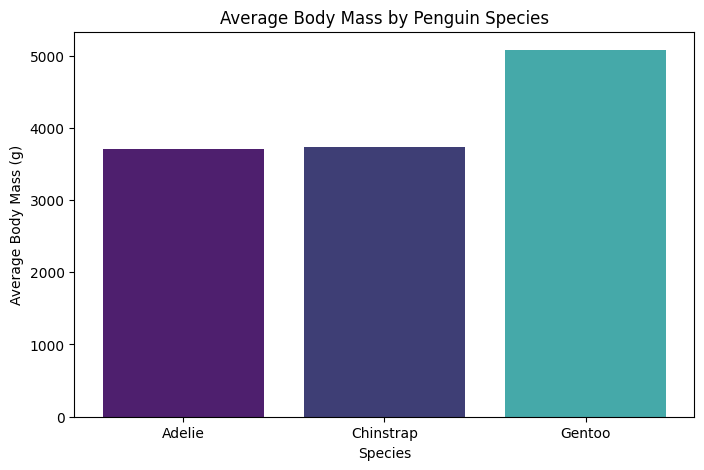

In [ ]:
avg_body_mass = df.groupby("species")["body_mass_g"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_body_mass.index, avg_body_mass.values, color=["#4E1F6E", "#3E3E75", "#45A9A9"])

plt.xlabel("Species")
plt.ylabel("Average Body Mass (g)")
plt.title("Average Body Mass by Penguin Species")

plt.show()

### Task 2

/tmp/ipykernel_2276/2893766297.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="species", palette=["#4E1F6E", "#3E3E75", "#45A9A9"])


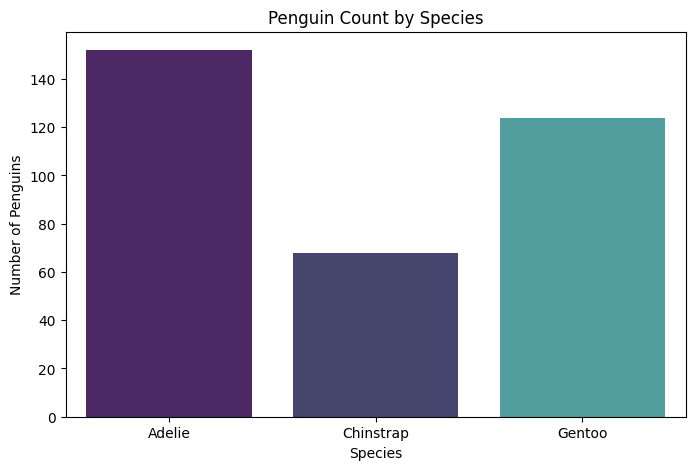

Most common category: Adelie


In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="species", palette=["#4E1F6E", "#3E3E75", "#45A9A9"])

plt.xlabel("Species")
plt.ylabel("Number of Penguins")
plt.title("Penguin Count by Species")

plt.show()

most_common = df["species"].value_counts().idxmax()
print("Most common category:", most_common)

### Task 3

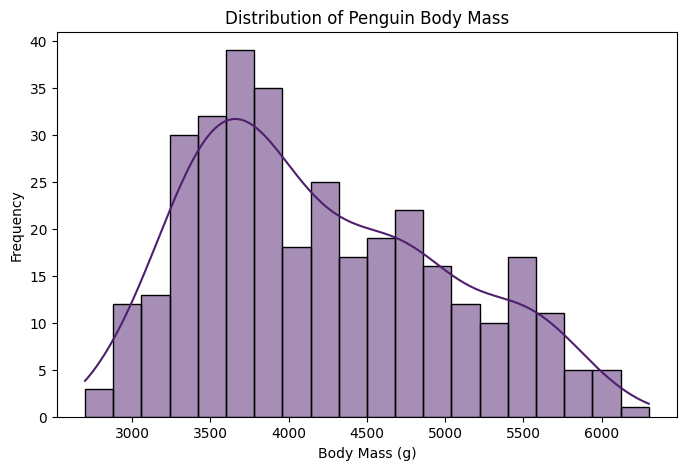

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="body_mass_g", bins=20, kde=True, color="#4E1F6E")

plt.xlabel("Body Mass (g)")
plt.ylabel("Frequency")
plt.title("Distribution of Penguin Body Mass")

plt.show()

The distribution is approximately bimodal (slightly right skewed) because penguins from different species have different body-mass ranges.

### Task 4

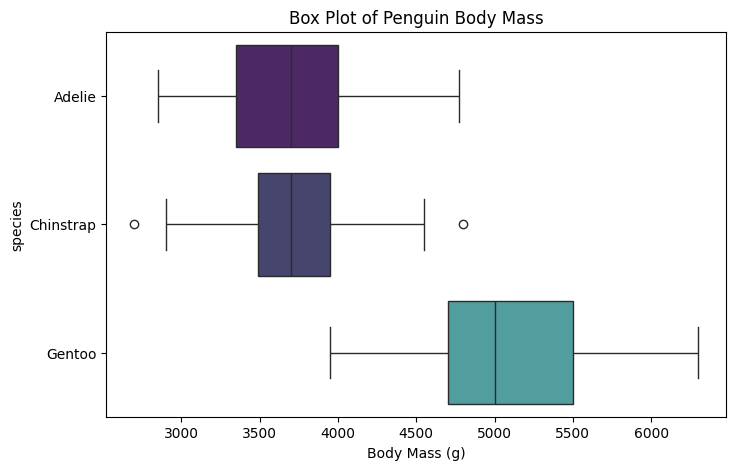

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="body_mass_g",
    y="species",
    hue="species",
    palette=["#4E1F6E", "#3E3E75", "#45A9A9"]
)

plt.xlabel("Body Mass (g)")
plt.title("Box Plot of Penguin Body Mass")

plt.show()

In [ ]:
body_mass = df["body_mass_g"].dropna()

Q1 = body_mass.quantile(0.25)
Q3 = body_mass.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

visual_outliers = body_mass[(body_mass < lower) | (body_mass > upper)]

print("Approximate number of outliers:", len(visual_outliers))

Approximate number of outliers: 0


### Task 5

In [ ]:
Q1 = df["body_mass_g"].quantile(0.25)
Q3 = df["body_mass_g"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["body_mass_g"] < lower) |
    (df["body_mass_g"] > upper)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of IQR outliers:", len(outliers))

Q1: 3550.0
Q3: 4750.0
IQR: 1200.0
Lower bound: 1750.0
Upper bound: 6550.0
Number of IQR outliers: 0


The IQR outlier count should correspond to the points appearing beyond the box plot whiskers.

### Task 6

In [ ]:
df["zscore"] = stats.zscore(df["body_mass_g"], nan_policy="omit")

outliers_z = df[df["zscore"].abs() > 3]

print("Number of Z-score outliers:", len(outliers_z))

Number of Z-score outliers: 0


In [ ]:
iqr_count = len(outliers)
zscore_count = len(outliers_z)

print("IQR outliers:", iqr_count)
print("Z-score outliers:", zscore_count)

IQR outliers: 0
Z-score outliers: 0


IQR and Z-score flag the same number of outliers.

### Task 7

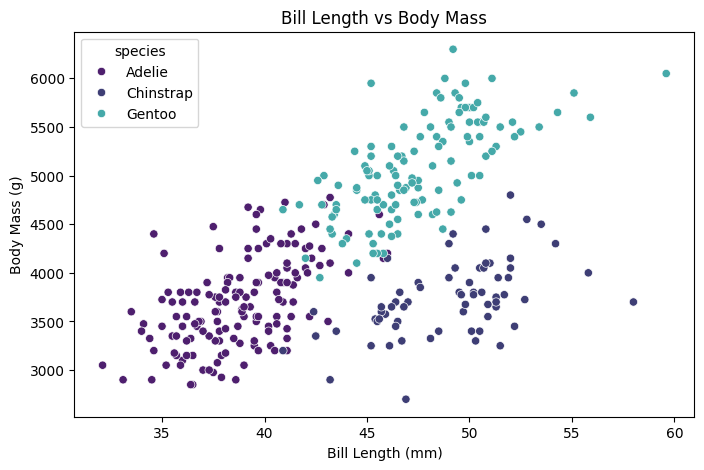

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="body_mass_g",
    hue="species",
    palette=["#4E1F6E", "#3E3E75", "#45A9A9"]
)

plt.xlabel("Bill Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Bill Length vs Body Mass")

plt.show()

In [ ]:
correlation = df[["bill_length_mm", "body_mass_g"]].corr().iloc[0, 1]

print("Correlation:", correlation)

if correlation > 0:
    print("Relationship: Positive")
elif correlation < 0:
    print("Relationship: Negative")
else:
    print("Relationship: None")

Correlation: 0.5951098244376295
Relationship: Positive


### Task 8

In [ ]:
ordered_df = (
    df.dropna(subset=["bill_length_mm", "body_mass_g"])
      .assign(
          bill_length_bin=lambda x: pd.cut(
              x["bill_length_mm"],
              bins=10
          )
      )
)

trend = (
    ordered_df.groupby("bill_length_bin", observed=True)["body_mass_g"]
    .mean()
    .reset_index()
)

trend["bill_length_mid"] = trend["bill_length_bin"].apply(lambda x: x.mid)

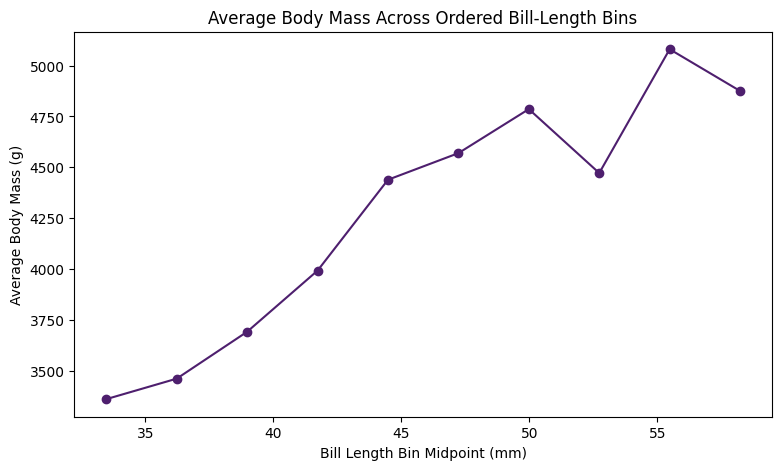

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    trend["bill_length_mid"],
    trend["body_mass_g"],
    marker="o",
    color="#4E1F6E"
)

plt.xlabel("Bill Length Bin Midpoint (mm)")
plt.ylabel("Average Body Mass (g)")
plt.title("Average Body Mass Across Ordered Bill-Length Bins")

plt.show()

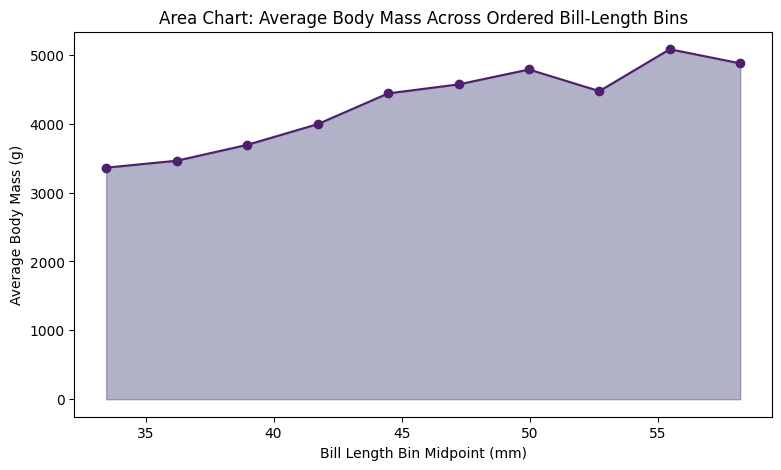

In [ ]:
plt.figure(figsize=(9, 5))

plt.fill_between(
    trend["bill_length_mid"],
    trend["body_mass_g"],
    alpha=0.4,
    color="#3E3E75"
)

plt.plot(
    trend["bill_length_mid"],
    trend["body_mass_g"],
    marker="o",
    color="#4E1F6E"
)

plt.xlabel("Bill Length Bin Midpoint (mm)")
plt.ylabel("Average Body Mass (g)")
plt.title("Area Chart: Average Body Mass Across Ordered Bill-Length Bins")

plt.show()

The area chart emphasizes the magnitude of the values through the filled region, while the line chart focuses more directly on the direction and change of the trend.

### Task 9

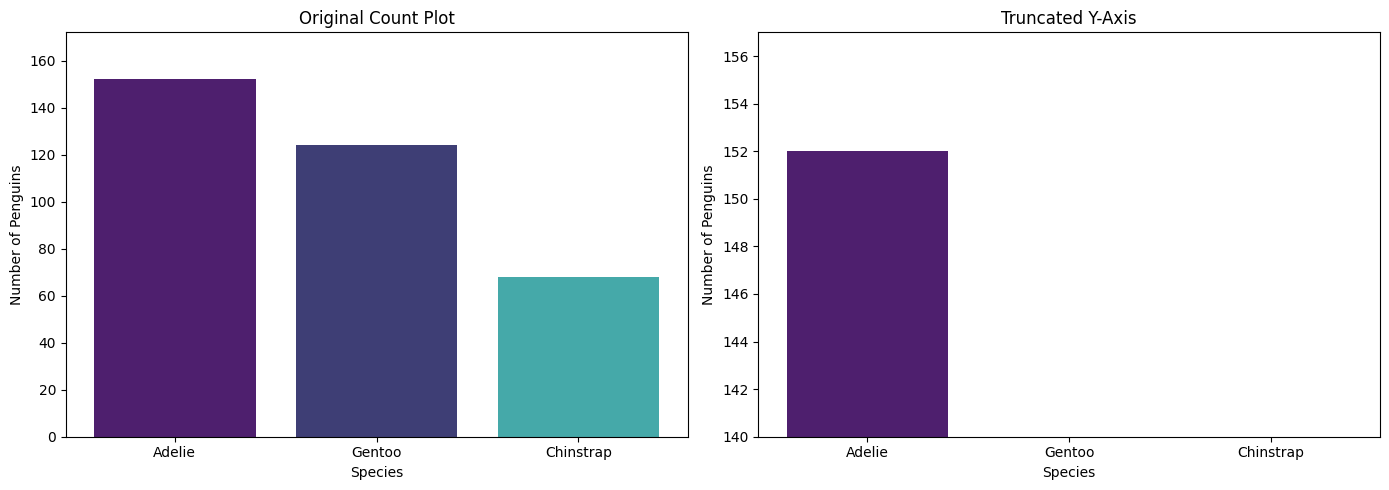

In [ ]:
species_counts = df["species"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(species_counts.index, species_counts.values, color=["#4E1F6E", "#3E3E75", "#45A9A9"])
axes[0].set_xlabel("Species")
axes[0].set_ylabel("Number of Penguins")
axes[0].set_title("Original Count Plot")
axes[0].set_ylim(0, species_counts.max() + 20)

axes[1].bar(species_counts.index, species_counts.values, color=["#4E1F6E", "#3E3E75", "#45A9A9"])
axes[1].set_xlabel("Species")
axes[1].set_ylabel("Number of Penguins")
axes[1].set_title("Truncated Y-Axis")
axes[1].set_ylim(140, species_counts.max() + 5)

plt.tight_layout()
plt.show()

The original chart starts at zero and shows the actual differences between species counts. The truncated y-axis makes relatively small differences appear much larger than they actually are. The underlying data remains unchanged, but the visual impression is distorted.